# 🏠 California Housing Price Prediction using Linear Regression

## 📌 Project Overview

This project aims to predict California housing prices using a Linear Regression model. It demonstrates a complete Machine Learning workflow, starting from data preprocessing to model evaluation.

### Project Workflow
- 📂 Data Loading
- 🧹 Data Cleaning
- 📊 Exploratory Data Analysis (EDA)
- ⚙️ Feature Engineering
- ✂️ Train-Test Split
- 🤖 Linear Regression Model
- 📈 Model Evaluation
- 📉 Result Visualization

---

## 🎯 Objective

To build a machine learning model that predicts the **median house value** based on housing-related features and evaluates its performance using regression metrics.

---

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

## 📊 Dataset

**Dataset:** California Housing Dataset

**Target Variable:** `median_house_value`

**Features Used:**
- Median Income
- Housing Median Age
- Total Rooms
- Total Bedrooms
- Population
- Households
- Latitude
- Longitude
- Ocean Proximity

# 📚 1. Import Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 2. Load Dataset

# 🔍 3. Data Understanding

In [24]:
df = pd.read_csv("/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv")
df.head()
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())


(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude     

# 🧹 4. Data Cleaning

In [25]:
df["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

# 📊 5. Exploratory Data Analysis (EDA)

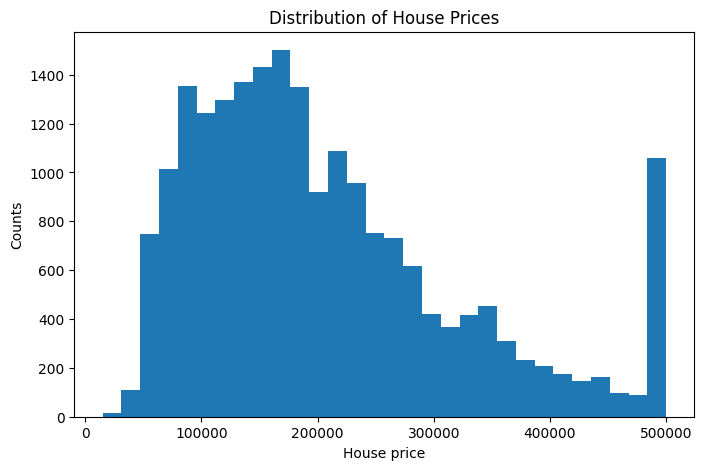

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df["median_house_value"], bins = 30)
plt.title("Distribution of House Prices")
plt.xlabel("House price")
plt.ylabel("Counts")
plt.show()

### 📖 Interpretation

The histogram shows the distribution of numerical features in the dataset. Most features are right-skewed, indicating that higher values occur less frequently. The target variable (`median_house_value`) also shows a concentration of values around the upper limit due to dataset capping.

In [27]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [28]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [29]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

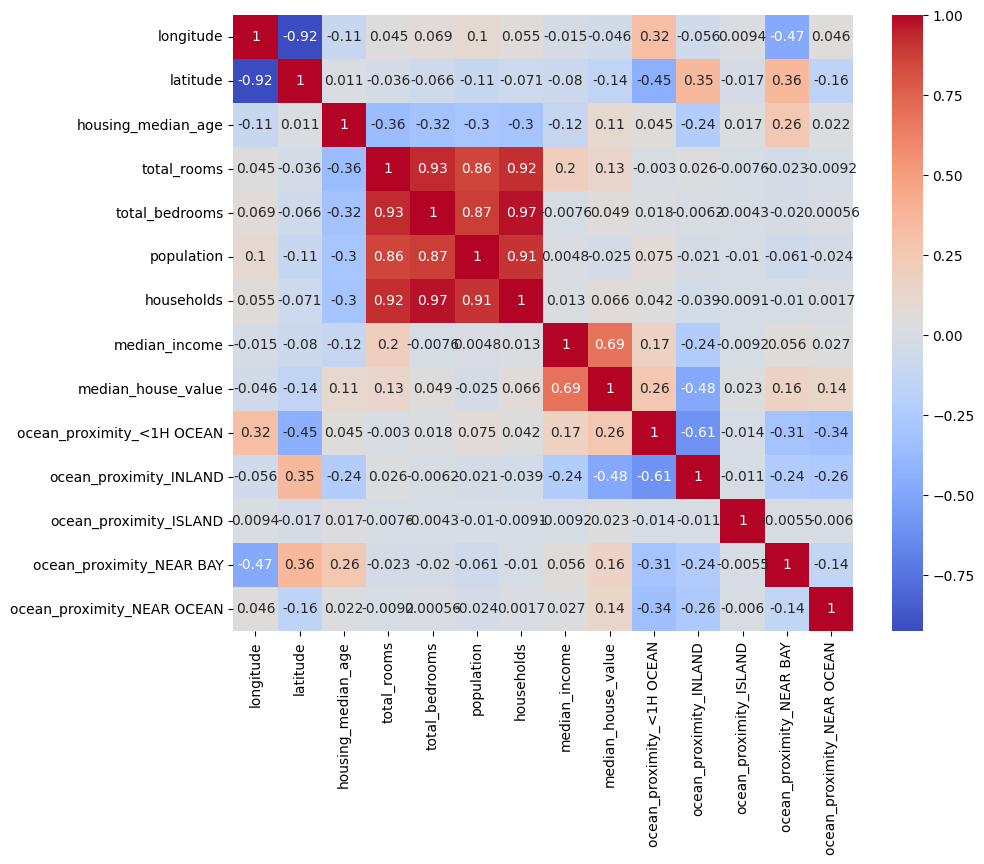

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only= True), annot=True, cmap="coolwarm")
plt.show()



### 📖 Interpretation

The correlation heatmap shows the relationship between numerical features. Median Income has the strongest positive correlation with the target variable (`median_house_value`), making it one of the most influential predictors.

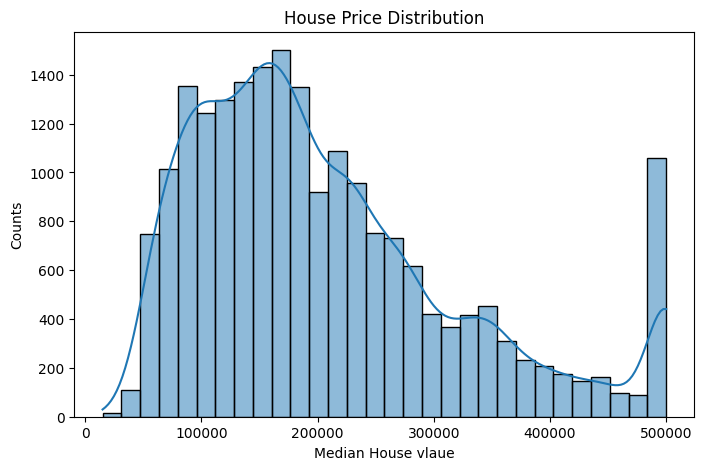

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=30, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Median House vlaue")
plt.ylabel("Counts")
plt.show()

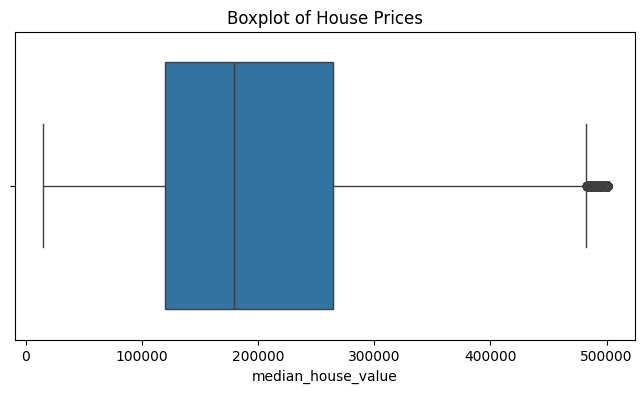

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["median_house_value"])
plt.title("Boxplot of House Prices")
plt.show()

### 📖 Interpretation

The boxplots reveal the presence of outliers in several numerical features such as total rooms, population, and households. These outliers may influence the performance of Linear Regression.

# ⚙️ 6. Feature Engineering

In [33]:

# STEP 1: One-Hot Encoding


import pandas as pd
import numpy as np

df = pd.get_dummies(df, columns=["ocean_proximity"], dtype=int)


# STEP 2: Features (X) and Target (y)


X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# STEP 3: Train-Test Split


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# STEP 4: Linear Regression Model


from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Model Training
model.fit(X_train, y_train)


# STEP 5: Prediction


predictions = model.predict(X_test)

print("First 5 Predictions:")
print(predictions[:5])


# STEP 6: Actual vs Predicted


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

print("\nFirst 10 Actual vs Predicted Values:")
print(comparison.head(10))

First 5 Predictions:
[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568]

First 10 Actual vs Predicted Values:
     Actual      Predicted
0   47700.0   54055.448899
1   45800.0  124225.338937
2  500001.0  255489.379492
3  218600.0  268002.431569
4  278000.0  262769.434816
5  158700.0  139606.303956
6  198200.0  290665.423914
7  157500.0  228264.876375
8  340000.0  256506.785610
9  446600.0  407923.858435


# ✂️ 7. Train-Test Split 
# 🤖 8. Model Training (Linear Regression)
# 🎯 9. Predictions
# 📈 10. Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 50670.73824097182
MSE : 4908476721.156623
RMSE : 70060.52184473524
R2 Score : 0.6254240620553602


# 📉 11. Result Visualizations

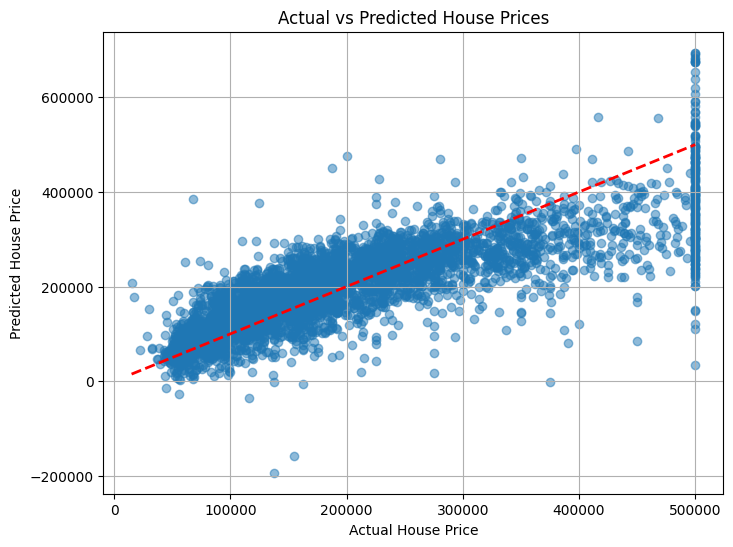

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha =0.5)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle= "--",
    color= "red",
    linewidth = 2
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)
plt.show()

### 📖 Interpretation

The scatter plot compares actual and predicted house prices. The red dashed line represents perfect predictions. Most data points follow the overall trend, indicating that the model has learned the relationship between features and house prices. Some deviation from the line is expected due to model limitations and dataset characteristics.

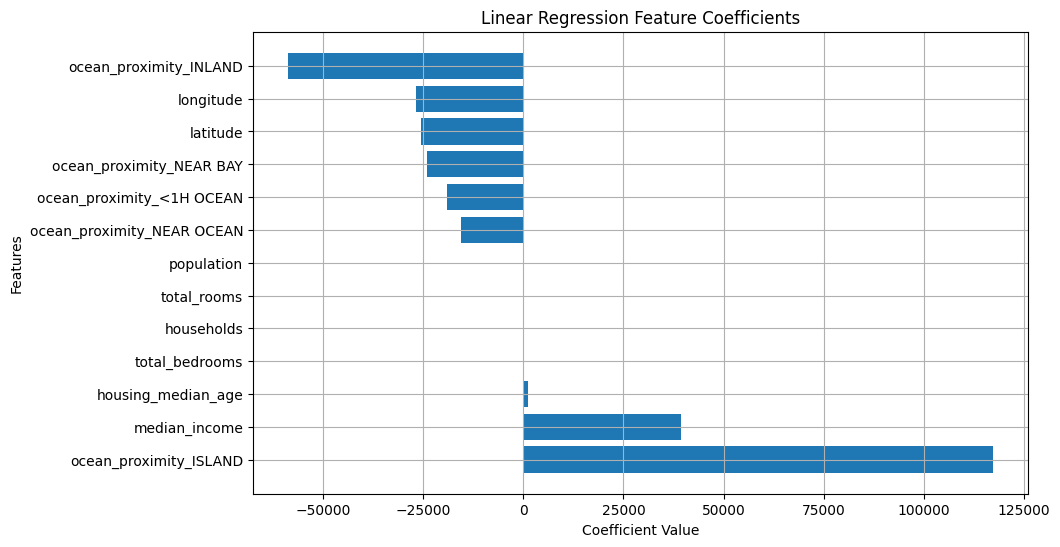

In [44]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Linear Regression Feature Coefficients")
plt.grid(True)
plt.show()

### 📖 Interpretation

This graph displays the coefficients learned by the Linear Regression model. Positive coefficients indicate that an increase in the feature tends to increase the predicted house price, while negative coefficients indicate the opposite. Median Income emerged as one of the most influential numerical features.

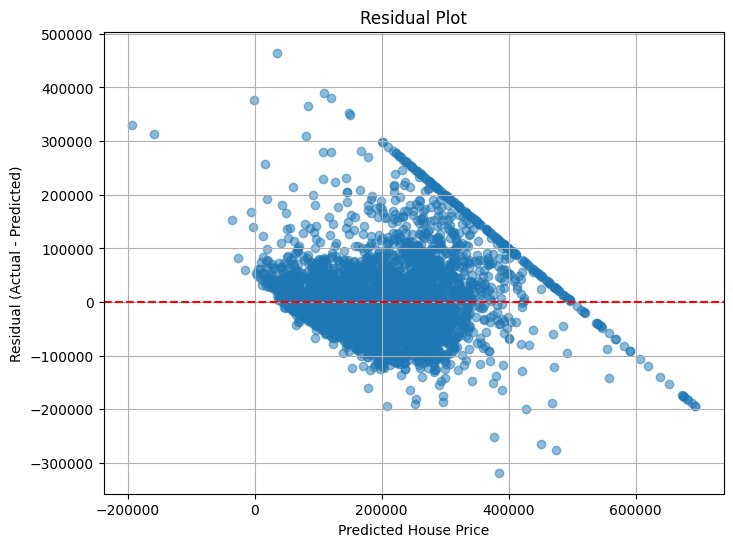

In [45]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.grid(True)

plt.show()